# NB 01 — MMASH: Activity & Sleep Exploration

> **Dataset**: MMASH — Multilevel Monitoring of Activity and Sleep in Healthy People  
> **Source**: [PhysioNet](https://physionet.org/content/mmash/1.0.0/) | N=22 subjects | 2-day recordings  
> **Signals**: Triaxial accelerometer · RR intervals · Sleep diary · Activity labels

## What this notebook does
1. Load and validate the MMASH dataset for User 1
2. Explore behavioral time distributions across 12 activity types
3. Analyse overnight RR interval dynamics and compute windowed HRV (RMSSD)
4. Identify physiological differences between sleep stages and active periods
5. Lay the groundwork for multi-subject analysis in subsequent notebooks

## Clinical / Product relevance
Wearable devices (Garmin, Apple Watch, Whoop) use exactly these signals to infer stress, recovery, and activity load.  
Understanding baseline distributions is step zero before building any classifier or health metric.

---

In [82]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Constants ──────────────────────────────────────────────────────────────
DATA_ROOT = '/Users/kcenia/Documents/data/physionet/multilevel-monitoring-of-activity-and-sleep-in-healthy-people-1.0.0/DataPaper'
USER_IDS  = list(range(1, 23))          # MMASH has 22 subjects
USER_ID   = 1                           # Primary subject for detailed analysis
DATA_PATH = os.path.join(DATA_ROOT, f'user_{USER_ID}/')
os.makedirs('../figures', exist_ok=True)

# Activity label map (from MMASH data paper)
ACTIVITY_MAP = {
    1: 'sleeping',         2: 'laying',          3: 'sitting', #sitting = studying, eating and driving 
    4: 'light_activity',   5: 'moderate_activity',6: 'vigorous_activity', #4. light movement, e.g. slow/medium walk, chores and work. 5. medium, e.g. fast walk and bike. 6. heavy, e.g. gym, running.
    7: 'eating',           8: 'small_screen',     9: 'large_screen',
    10: 'caffeine',        11: 'smoking',         12: 'alcohol'
}

# Semantic colour groups for plotting
COLOUR_MAP = {
    'sleeping': '#7B68EE',       'laying': '#9B8FD6',
    'sitting': '#4FC3F7',        'small_screen': '#29B6F6',
    'large_screen': '#0288D1',
    'light_activity': '#66BB6A', 'moderate_activity': '#43A047',
    'vigorous_activity': '#2E7D32',
    'eating': '#FFA726',         'caffeine': '#FF7043',
    'smoking': '#BDBDBD',        'alcohol': '#EF5350',
}

print(f'✓ Config loaded — analysing User {USER_ID}')

✓ Config loaded — analysing User 1


## 1. Load & Validate Data

In [83]:
def load_user(user_id: int, data_root: str) -> dict:
    """Load all MMASH files for a given subject. Returns dict of DataFrames."""
    path = os.path.join(data_root, f'user_{user_id}/')
    files = {'activity': 'Activity.csv', 'rr': 'RR.csv', 'sleep': 'sleep.csv', 
             'actigraph': 'Actigraph.csv', 'questionnaire': 'questionnaire.csv', 
              'saliva': 'saliva.csv', 'user_info': 'user_info.csv' }
    data = {}
    for key, fname in files.items():
        fpath = os.path.join(path, fname)
        if os.path.exists(fpath):
            data[key] = pd.read_csv(fpath)
        else:
            print(f'  [WARN] Missing: {fpath}')
    return data


# ── Load data ───────────────────────────────────────────────────────────────
data = load_user(USER_ID, DATA_ROOT)
activity = data['activity']
rr       = data['rr']
sleep    = data['sleep']


# ── RR processing (canonical pipeline) ──────────────────────────────────────
rr.columns = rr.columns.str.strip()

# Convert IBI (seconds → ms)
rr["rr_ms"] = pd.to_numeric(rr["ibi_s"], errors="coerce") * 1000

# Filter physiological range
rr_clean = rr[(rr["rr_ms"] > 300) & (rr["rr_ms"] < 2000)].copy()

# Compute HR
rr_clean["hr_bpm"] = 60_000 / rr_clean["rr_ms"]


# ── QC summary ──────────────────────────────────────────────────────────────
print('=== Data shapes ===')
for name, df in data.items():
    nulls = df.isnull().sum().sum()
    print(f'  {name:12s}: {df.shape}  |  nulls={nulls}')

print('\n=== RR quality check ===')
print(rr_clean["rr_ms"].describe())

print(f'\nOriginal RR rows: {len(rr)}')
print(f'Clean RR rows:    {len(rr_clean)}')
print(f'Retained:         {len(rr_clean)/len(rr)*100:.1f}%')

print(f'\nRR range:')
print(f'  min={rr_clean["rr_ms"].min():.0f} ms  max={rr_clean["rr_ms"].max():.0f} ms')

print(f'\nMean HR: {rr_clean["hr_bpm"].mean():.1f} bpm')


# ── Use clean RR from now on ────────────────────────────────────────────────
rr = rr_clean

=== Data shapes ===
  activity    : (32, 5)  |  nulls=1
  rr          : (91858, 5)  |  nulls=0
  sleep       : (2, 17)  |  nulls=0
  actigraph   : (67936, 13)  |  nulls=0
  questionnaire: (1, 20)  |  nulls=0
  saliva      : (2, 4)  |  nulls=0
  user_info   : (1, 5)  |  nulls=0

=== RR quality check ===
count    91408.000000
mean       713.897930
std        157.918678
min        301.000000
25%        598.000000
50%        680.000000
75%        814.000000
max       1862.000000
Name: rr_ms, dtype: float64

Original RR rows: 91858
Clean RR rows:    91408
Retained:         99.5%

RR range:
  min=301 ms  max=1862 ms

Mean HR: 88.1 bpm


In [84]:
data["activity"]

,Unnamed: 0,Activity,Start,End,Day
0,0,2,10:00,10:22,1
1,1,9,10:37,10:40,1
2,2,10,10:40,10:45,1
3,3,6,10:55,11:00,1
4,4,2,11:00,11:20,1
5,5,7,12:00,13:00,1
6,6,4,13:30,13:35,1
7,7,10,13:35,13:40,1
8,8,3,13:40,13:45,1
9,9,6,13:55,14:30,1


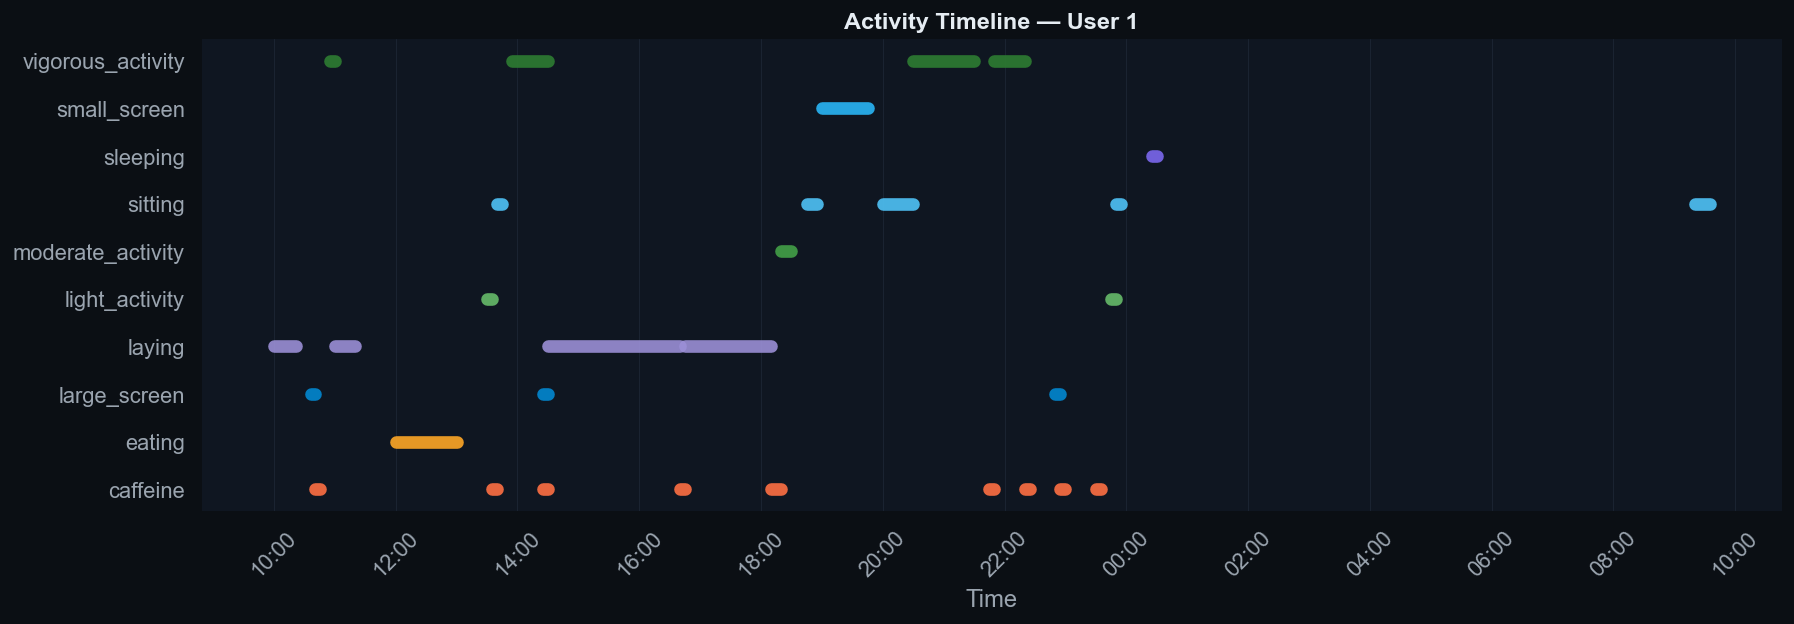

In [85]:
import matplotlib.dates as mdates
import os

os.makedirs("../figures", exist_ok=True)

# ── Prepare activity timeline ──────────────────────────────────────────────
activity_tl = data["activity"].copy()
activity_tl.columns = activity_tl.columns.str.strip()

activity_tl["activity_label"] = activity_tl["Activity"].map(ACTIVITY_MAP).fillna("unknown")

activity_tl["Start_dt"] = pd.to_datetime(
    "1900-01-" + activity_tl["Day"].astype(str).str.zfill(2) + " " + activity_tl["Start"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

activity_tl["End_dt"] = pd.to_datetime(
    "1900-01-" + activity_tl["Day"].astype(str).str.zfill(2) + " " + activity_tl["End"],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# Fix intervals crossing midnight
overnight_mask = activity_tl["End_dt"] < activity_tl["Start_dt"]
activity_tl.loc[overnight_mask, "End_dt"] += pd.Timedelta(days=1)

activity_tl["duration_min"] = (
    activity_tl["End_dt"] - activity_tl["Start_dt"]
).dt.total_seconds() / 60

activity_tl = activity_tl.dropna(subset=["Start_dt", "End_dt", "duration_min"])
activity_tl = activity_tl[activity_tl["duration_min"] > 0].copy()
activity_tl = activity_tl.sort_values(["Day", "Start_dt"]).reset_index(drop=True)

# ── Plot ───────────────────────────────────────────────────────────────────
plt.style.use("dark_background")

labels = sorted(activity_tl["activity_label"].unique())
label_to_y = {label: i for i, label in enumerate(labels)}

fig, ax = plt.subplots(figsize=(14, 5))

fig.patch.set_facecolor("#0B0F14")
ax.set_facecolor("#0F1621")

for _, row in activity_tl.iterrows():
    label = row["activity_label"]
    y = label_to_y[label]

    ax.plot(
        [row["Start_dt"], row["End_dt"]],
        [y, y],
        linewidth=7,
        solid_capstyle="round",
        color=COLOUR_MAP.get(label, "#90A4AE"),  # original colors
        alpha=0.9
    )

ax.set_yticks(list(label_to_y.values()))
ax.set_yticklabels(list(label_to_y.keys()), color="#9AA4AF")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

ax.set_xlabel("Time", color="#9AA4AF")
ax.set_ylabel("")
ax.set_title(
    f"Activity Timeline — User {USER_ID}",
    fontsize=13,
    fontweight="bold",
    color="#E6EDF3"
)

ax.grid(False)
ax.grid(axis="x", color="#253041", linewidth=0.6, alpha=0.5)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", colors="#9AA4AF")
ax.tick_params(axis="y", colors="#9AA4AF")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../figures/01_activity_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Behavioural Time Distribution

How does this subject allocate their time across the 12 recorded activity types?

Overnight-corrected rows: 0


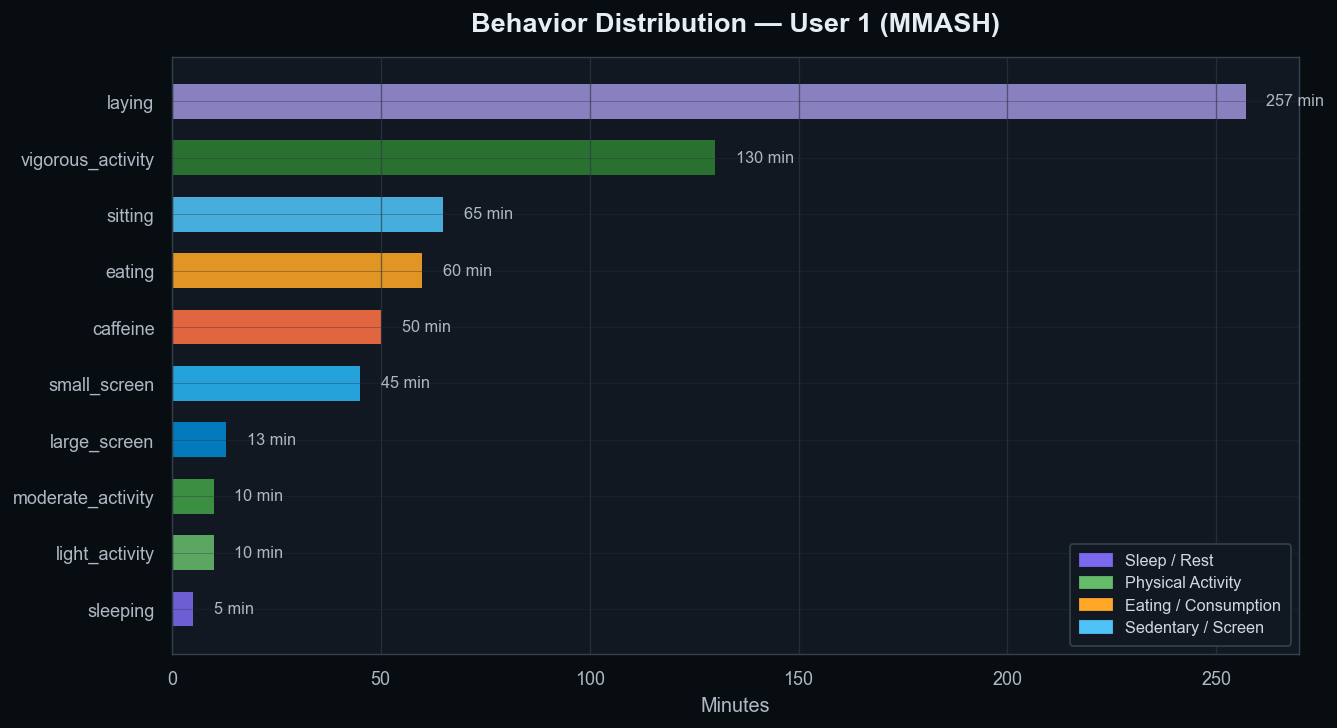

In [86]:
# ── Parse timestamps and compute durations ─────────────────────────────────
activity['activity_label'] = activity['Activity'].map(ACTIVITY_MAP)
activity['Start'] = pd.to_datetime(activity['Start'], format='%H:%M')
activity['End']   = pd.to_datetime(activity['End'],   format='%H:%M')
activity['duration_min'] = (activity['End'] - activity['Start']).dt.total_seconds() / 60

# Edge case: overnight activities (End < Start) — add 24h
mask = activity['duration_min'] < 0
activity.loc[mask, 'duration_min'] += 1440
print(f'Overnight-corrected rows: {mask.sum()}')

# ── Aggregate ──────────────────────────────────────────────────────────────
agg = (activity.groupby('activity_label')['duration_min']
               .sum()
               .sort_values(ascending=True))

colours = [COLOUR_MAP.get(lbl, '#90A4AE') for lbl in agg.index]

# fig, ax = plt.subplots(figsize=(9, 5))
# bars = ax.barh(agg.index, agg.values, color=colours, alpha=0.9, height=0.65)

# for bar, val in zip(bars, agg.values):
#     ax.text(val + 5, bar.get_y() + bar.get_height()/2,
#             f'{val:.0f} min', va='center', fontsize=9)

# ax.set_xlabel('Total Minutes')
# ax.set_title('Behavior Distribution — User 1 (MMASH)', fontsize=13, fontweight='bold')

# legend_items = [
#     mpatches.Patch(color='#7B68EE', label='Sleep / Rest'),
#     mpatches.Patch(color='#66BB6A', label='Physical Activity'),
#     mpatches.Patch(color='#FFA726', label='Eating / Consumption'),
#     mpatches.Patch(color='#4FC3F7', label='Sedentary / Screen'),
# ]
# ax.legend(handles=legend_items, loc='lower right', fontsize=9)
# plt.tight_layout()
# plt.savefig('../figures/01_behavior_distribution.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f'\nTotal recorded time: {agg.sum():.0f} min  ({agg.sum()/60:.1f} h)')
# ── Plot (UI-consistent aesthetics, original colours) ───────────────────────
# ── Plot: dark card style with visible grid through bars ────────────────────
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10.5, 5.8))

# Backgrounds
fig.patch.set_facecolor("#080D12")   # outer background
ax.set_facecolor("#111822")          # plot panel

# Bars
bars = ax.barh(
    agg.index,
    agg.values,
    color=[COLOUR_MAP.get(lbl, "#90A4AE") for lbl in agg.index],
    height=0.62,
    edgecolor="none",
    linewidth=0,
    alpha=0.88,
    zorder=2
)

# Grid ABOVE bars, like the reference
ax.set_axisbelow(False)
ax.grid(
    axis="x",
    color="#2E3A46",
    linewidth=0.75,
    alpha=0.65,
    zorder=5
)
ax.grid(
    axis="y",
    color="#26313B",
    linewidth=0.55,
    alpha=0.35,
    zorder=5
)

# Value labels
for bar, val in zip(bars, agg.values):
    ax.text(
        val + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f} min",
        va="center",
        fontsize=9,
        color="#AEB7C2",
        zorder=6
    )

# Labels / title
ax.set_xlabel("Minutes", color="#AEB7C2", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Behavior Distribution — User 1 (MMASH)",
    fontsize=15,
    fontweight="bold",
    color="#E6EDF3",
    pad=14
)

# Ticks
ax.tick_params(axis="x", colors="#AEB7C2", labelsize=10)
ax.tick_params(axis="y", colors="#AEB7C2", labelsize=10)

# Subtle panel border, not fully invisible
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#34404C")
    spine.set_linewidth(0.8)

# Legend
legend_items = [
    mpatches.Patch(color="#7B68EE", label="Sleep / Rest"),
    mpatches.Patch(color="#66BB6A", label="Physical Activity"),
    mpatches.Patch(color="#FFA726", label="Eating / Consumption"),
    mpatches.Patch(color="#4FC3F7", label="Sedentary / Screen"),
]

leg = ax.legend(
    handles=legend_items,
    loc="lower right",
    fontsize=9,
    frameon=True,
    borderpad=0.6,
    labelspacing=0.45
)

leg.get_frame().set_facecolor("#111822")
leg.get_frame().set_edgecolor("#34404C")
leg.get_frame().set_alpha(0.95)

for text in leg.get_texts():
    text.set_color("#D0D7DE")

plt.tight_layout()
plt.savefig("../figures/01_behavior_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. RR Interval Dynamics

RR intervals are the time between consecutive heartbeats (in milliseconds).  
Higher and more variable RR → lower heart rate, higher parasympathetic tone (rest/recovery).  
Lower and stable RR → faster heart rate, sympathetic activation (exercise/stress).

In [87]:
# ── Parse RR timestamps correctly ──────────────────────────────────────────
rr.columns = rr.columns.str.strip()

# Time
time_col = "time" if "time" in rr.columns else [c for c in rr.columns if "time" in c.lower()][0]
rr["time_dt"] = pd.to_datetime(rr[time_col], format="%H:%M:%S", errors="coerce")

# RR / IBI: MMASH uses ibi_s = seconds
if "ibi_s" in rr.columns:
    rr["rr_ms"] = pd.to_numeric(rr["ibi_s"], errors="coerce") * 1000
elif "rr_ms" in rr.columns:
    rr["rr_ms"] = pd.to_numeric(rr["rr_ms"], errors="coerce")
else:
    raise ValueError("Could not find RR column. Expected 'ibi_s' or 'rr_ms'.")

# Clean physiological range
rr_clean = rr[(rr["rr_ms"] > 300) & (rr["rr_ms"] < 2000)].copy()
rr_clean["hr_bpm"] = 60_000 / rr_clean["rr_ms"]

print(f"RR intervals retained: {len(rr_clean)}/{len(rr)} ({len(rr_clean)/len(rr)*100:.1f}%)")
print(f"Mean HR: {rr_clean.hr_bpm.mean():.1f} bpm  |  Mean RR: {rr_clean.rr_ms.mean():.0f} ms")

RR intervals retained: 91408/91408 (100.0%)
Mean HR: 88.1 bpm  |  Mean RR: 714 ms


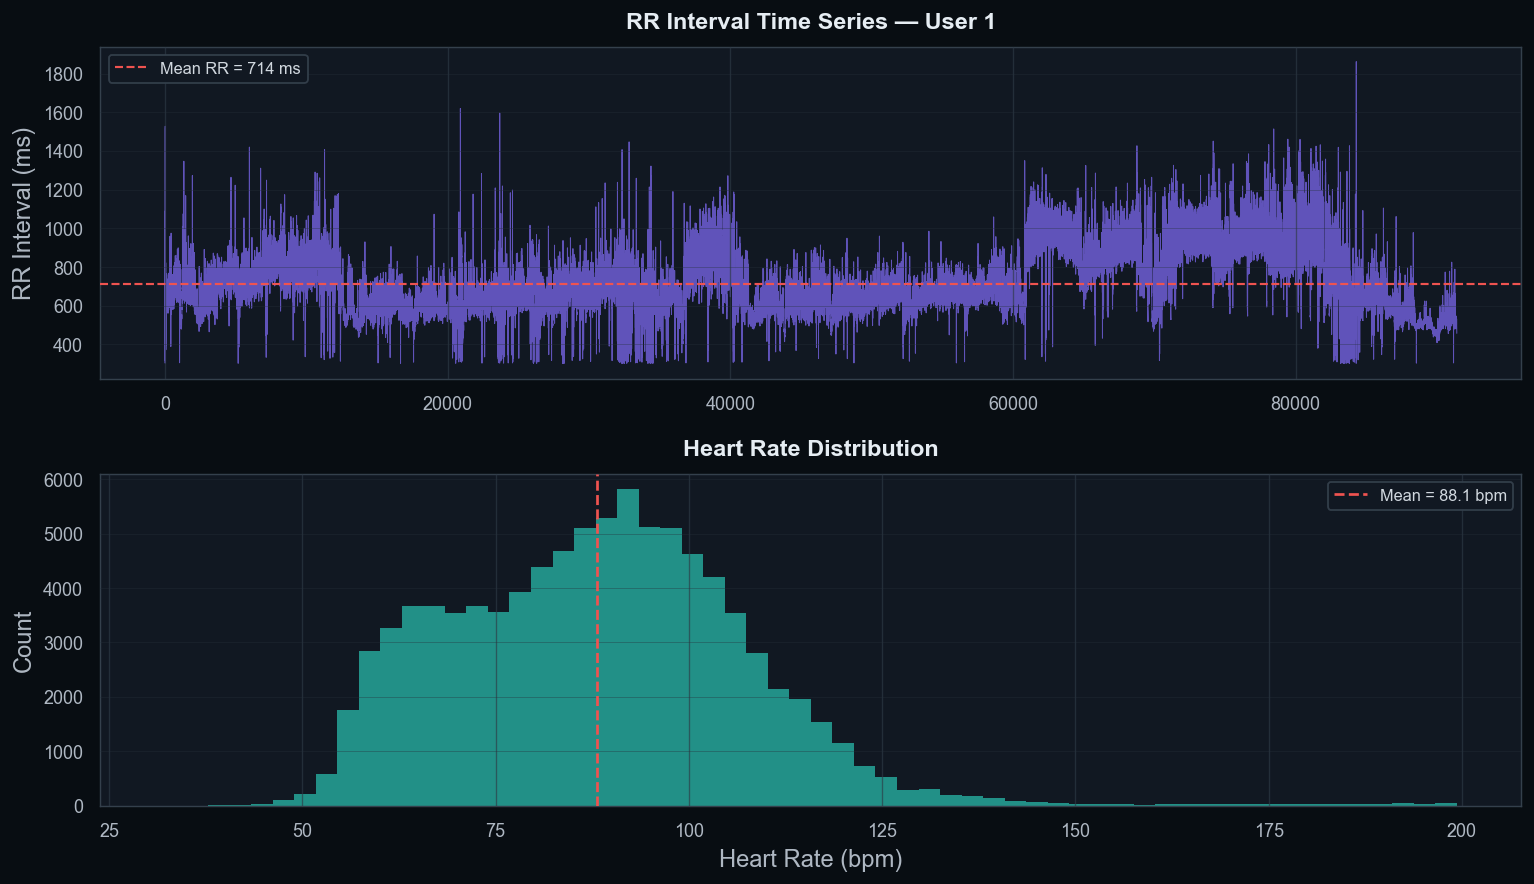

In [88]:
# ── RR plots: dark card style ──────────────────────────────────────────────
plt.style.use("dark_background")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

fig.patch.set_facecolor("#080D12")

for ax in axes:
    ax.set_facecolor("#111822")
    ax.set_axisbelow(False)

    ax.grid(axis="x", color="#2E3A46", linewidth=0.75, alpha=0.65, zorder=5)
    ax.grid(axis="y", color="#26313B", linewidth=0.55, alpha=0.35, zorder=5)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#34404C")
        spine.set_linewidth(0.8)

    ax.tick_params(colors="#AEB7C2", labelsize=10)

# RR time series
axes[0].plot(
    range(len(rr_clean)),
    rr_clean["rr_ms"],
    lw=0.55,
    color="#7B68EE",
    alpha=0.75,
    zorder=2
)

axes[0].axhline(
    rr_clean["rr_ms"].mean(),
    color="#EF5350",
    lw=1.2,
    linestyle="--",
    label=f"Mean RR = {rr_clean['rr_ms'].mean():.0f} ms",
    zorder=6
)

axes[0].set_ylabel("RR Interval (ms)", color="#AEB7C2")
axes[0].set_title(
    f"RR Interval Time Series — User {USER_ID}",
    fontsize=13,
    fontweight="bold",
    color="#E6EDF3",
    pad=10
)

# HR distribution
axes[1].hist(
    rr_clean["hr_bpm"],
    bins=60,
    color="#26A69A",
    alpha=0.85,
    edgecolor="none",
    linewidth=0,
    zorder=2
)

axes[1].axvline(
    rr_clean["hr_bpm"].mean(),
    color="#EF5350",
    lw=1.5,
    linestyle="--",
    label=f"Mean = {rr_clean['hr_bpm'].mean():.1f} bpm",
    zorder=6
)

axes[1].set_xlabel("Heart Rate (bpm)", color="#AEB7C2")
axes[1].set_ylabel("Count", color="#AEB7C2")
axes[1].set_title(
    "Heart Rate Distribution",
    fontsize=13,
    fontweight="bold",
    color="#E6EDF3",
    pad=10
)

# Legends
for ax in axes:
    leg = ax.legend(fontsize=9, frameon=True)
    leg.get_frame().set_facecolor("#111822")
    leg.get_frame().set_edgecolor("#34404C")
    leg.get_frame().set_alpha(0.95)
    for text in leg.get_texts():
        text.set_color("#D0D7DE")

plt.tight_layout()
plt.savefig("../figures/01_rr_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

In [90]:
def compute_rmssd(rr_values: np.ndarray) -> float:
    """RMSSD = sqrt(mean of squared successive differences of RR intervals)."""
    if len(rr_values) < 2:
        return np.nan
    diffs = np.diff(rr_values)
    return np.sqrt(np.mean(diffs ** 2))


def compute_pnn50(rr_values: np.ndarray) -> float:
    """pNN50 = % of successive RR differences > 50 ms."""
    if len(rr_values) < 2:
        return np.nan
    return 100 * np.mean(np.abs(np.diff(rr_values)) > 50)


# Use smoother HRV windows than 50 beats
WINDOW = 300
HOP = 150

rr_clean = rr_clean.copy()
rr_clean["elapsed_hours"] = rr_clean["rr_ms"].cumsum() / 1000 / 3600

rr_arr = rr_clean["rr_ms"].values

rmssd_vals, pnn50_vals, window_idx = [], [], []

for start in range(0, len(rr_arr) - WINDOW, HOP):
    window = rr_arr[start:start + WINDOW]
    rmssd_vals.append(compute_rmssd(window))
    pnn50_vals.append(compute_pnn50(window))
    window_idx.append(start + WINDOW // 2)

hrv_df = pd.DataFrame({
    "window_center": window_idx,
    "RMSSD": rmssd_vals,
    "pNN50": pnn50_vals
})

hrv_df["elapsed_hours"] = np.interp(
    hrv_df["window_center"],
    np.arange(len(rr_clean)),
    rr_clean["elapsed_hours"]
)

print(f"HRV windows computed: {len(hrv_df)}")
print(f"Mean RMSSD : {hrv_df.RMSSD.mean():.1f} ms")
print(f"Mean pNN50 : {hrv_df.pNN50.mean():.1f}%")

HRV windows computed: 608
Mean RMSSD : 57.7 ms
Mean pNN50 : 20.8%


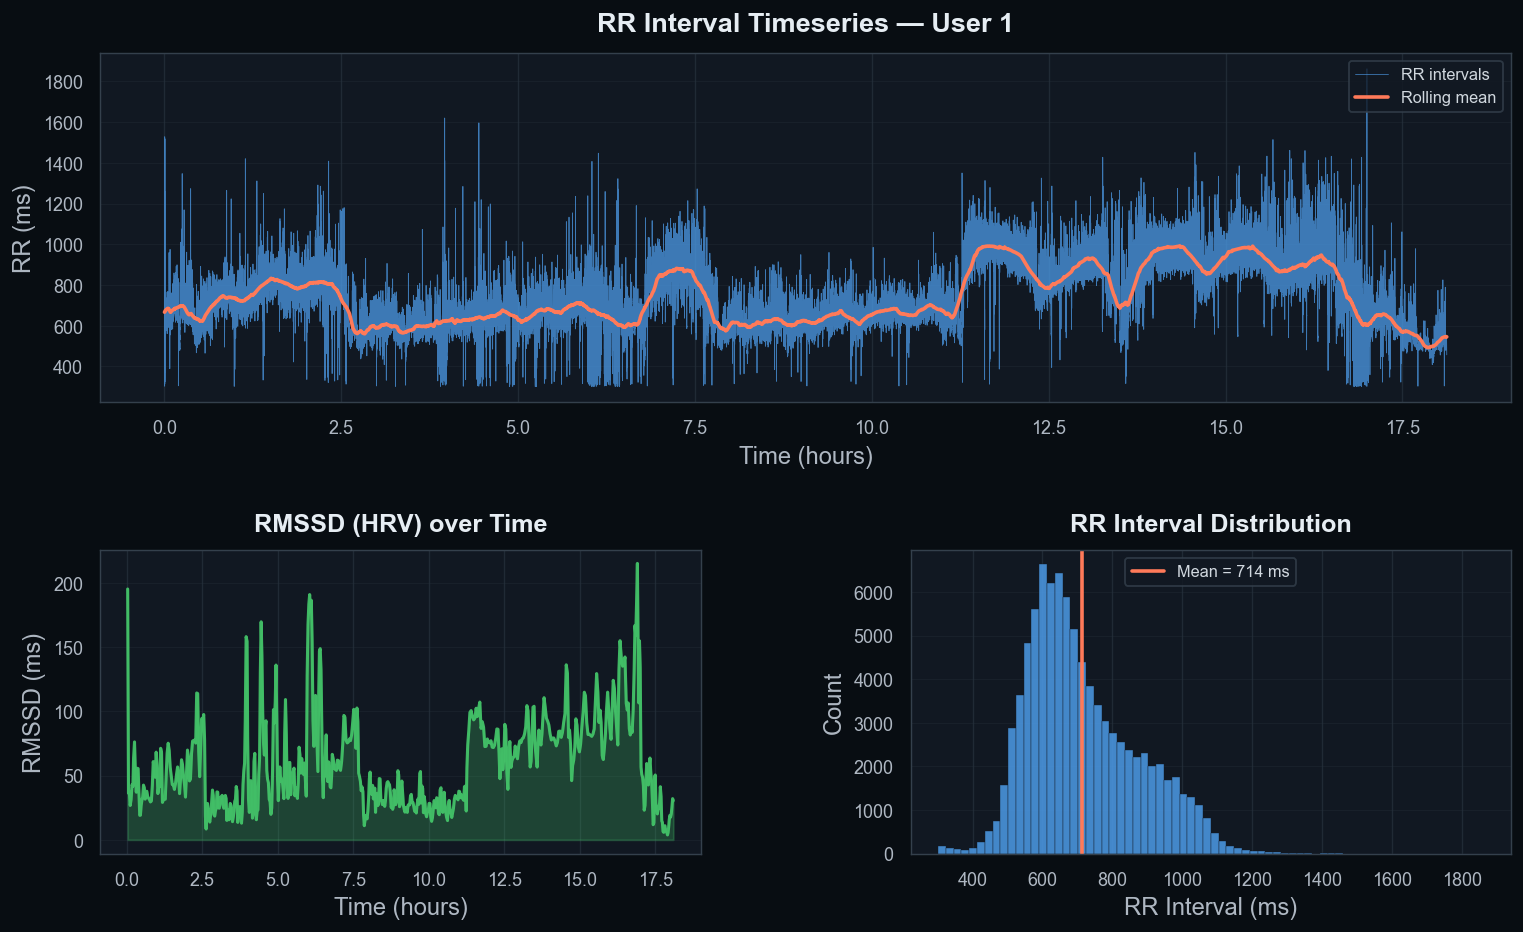

In [91]:
plt.style.use("dark_background")

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor("#080D12")

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.15, 1],
    hspace=0.45,
    wspace=0.35
)

ax_rr = fig.add_subplot(gs[0, :])
ax_hrv = fig.add_subplot(gs[1, 0])
ax_hist = fig.add_subplot(gs[1, 1])

for ax in [ax_rr, ax_hrv, ax_hist]:
    ax.set_facecolor("#111822")
    ax.grid(axis="x", color="#2E3A46", linewidth=0.75, alpha=0.55)
    ax.grid(axis="y", color="#26313B", linewidth=0.55, alpha=0.35)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#34404C")
        spine.set_linewidth(0.8)

    ax.tick_params(colors="#AEB7C2", labelsize=10)

# ── RR interval time series ────────────────────────────────────────────────
ax_rr.plot(
    rr_clean["elapsed_hours"],
    rr_clean["rr_ms"],
    color="#4C9BE8",
    lw=0.45,
    alpha=0.75,
    label="RR intervals"
)

rolling_rr = (
    rr_clean["rr_ms"]
    .rolling(window=1500, center=True, min_periods=100)
    .mean()
)

ax_rr.plot(
    rr_clean["elapsed_hours"],
    rolling_rr,
    color="#FF7A59",
    lw=2.0,
    label="Rolling mean"
)

ax_rr.set_title(
    f"RR Interval Timeseries — User {USER_ID}",
    fontsize=15,
    fontweight="bold",
    color="#E6EDF3",
    pad=12
)
ax_rr.set_xlabel("Time (hours)", color="#AEB7C2")
ax_rr.set_ylabel("RR (ms)", color="#AEB7C2")

leg = ax_rr.legend(loc="upper right", fontsize=9, frameon=True)
leg.get_frame().set_facecolor("#111822")
leg.get_frame().set_edgecolor("#34404C")
for text in leg.get_texts():
    text.set_color("#D0D7DE")

# ── RMSSD over time ────────────────────────────────────────────────────────
ax_hrv.plot(
    hrv_df["elapsed_hours"],
    hrv_df["RMSSD"],
    color="#45C96B",
    lw=1.7,
    alpha=0.9
)

ax_hrv.fill_between(
    hrv_df["elapsed_hours"],
    hrv_df["RMSSD"],
    color="#45C96B",
    alpha=0.25
)

ax_hrv.set_title(
    "RMSSD (HRV) over Time",
    fontsize=14,
    fontweight="bold",
    color="#E6EDF3",
    pad=10
)
ax_hrv.set_xlabel("Time (hours)", color="#AEB7C2")
ax_hrv.set_ylabel("RMSSD (ms)", color="#AEB7C2")

# ── RR distribution ────────────────────────────────────────────────────────
ax_hist.hist(
    rr_clean["rr_ms"],
    bins=70,
    color="#4C9BE8",
    alpha=0.85,
    edgecolor="#111822",
    linewidth=0.25
)

mean_rr = rr_clean["rr_ms"].mean()

ax_hist.axvline(
    mean_rr,
    color="#FF7A59",
    lw=2,
    label=f"Mean = {mean_rr:.0f} ms"
)

ax_hist.set_title(
    "RR Interval Distribution",
    fontsize=14,
    fontweight="bold",
    color="#E6EDF3",
    pad=10
)
ax_hist.set_xlabel("RR Interval (ms)", color="#AEB7C2")
ax_hist.set_ylabel("Count", color="#AEB7C2")

leg = ax_hist.legend(loc="upper center", fontsize=9, frameon=True)
leg.get_frame().set_facecolor("#111822")
leg.get_frame().set_edgecolor("#34404C")
for text in leg.get_texts():
    text.set_color("#D0D7DE")

plt.savefig("../figures/01_rr_hrv_composite.png", dpi=150, bbox_inches="tight")
plt.show()

In [92]:
SLEEP_LABELS = {"sleeping", "laying"}

sleep_rows = activity[activity["activity_label"].isin(SLEEP_LABELS)]
wake_rows = activity[~activity["activity_label"].isin(SLEEP_LABELS)]

def rmssd_for_activity_rows(act_df, rr_arr, n_beats=300):
    """Approximation: sample RR windows proportional to activity duration."""
    results = []

    for _, row in act_df.iterrows():
        dur = max(row.get("duration_min", 1), 1)
        n_samples = max(int(dur // 10), 1)

        for _ in range(n_samples):
            if len(rr_arr) <= n_beats:
                continue

            start = np.random.randint(0, len(rr_arr) - n_beats)
            window = rr_arr[start:start + n_beats]
            results.append(compute_rmssd(window))

    return np.array(results)


np.random.seed(42)

sleep_rmssd = rmssd_for_activity_rows(sleep_rows, rr_arr, n_beats=300)
wake_rmssd = rmssd_for_activity_rows(wake_rows, rr_arr, n_beats=300)

stat, p_val = stats.mannwhitneyu(
    sleep_rmssd,
    wake_rmssd,
    alternative="greater"
)

print(f"Sleep RMSSD : {sleep_rmssd.mean():.1f} ± {sleep_rmssd.std():.1f} ms  (n={len(sleep_rmssd)})")
print(f"Wake RMSSD  : {wake_rmssd.mean():.1f} ± {wake_rmssd.std():.1f} ms  (n={len(wake_rmssd)})")
print(f"Mann–Whitney U: stat={stat:.0f}, p={p_val:.4f}")
print(f'Result: {"Sleep RMSSD significantly higher ✓" if p_val < 0.05 else "No significant difference"}')

ValueError: cannot convert float NaN to integer

NameError: name 'wake_rmssd' is not defined

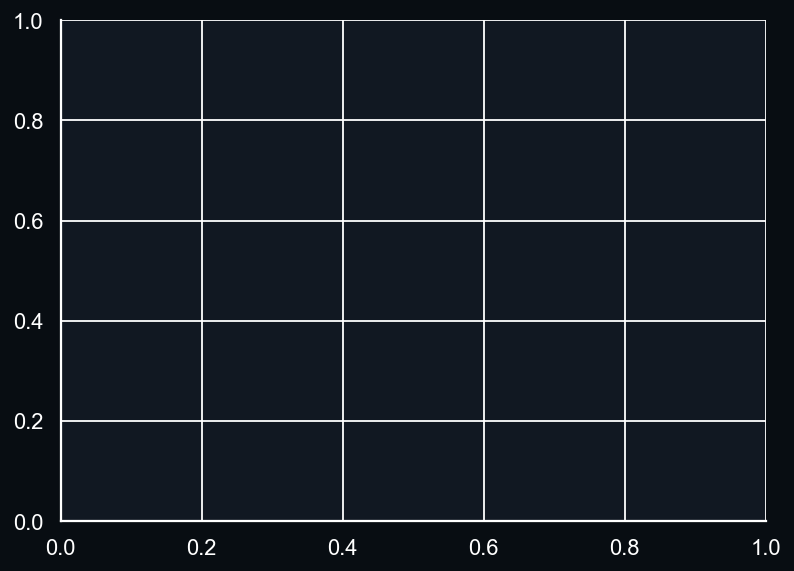

In [93]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#080D12")
ax.set_facecolor("#111822")

box_data = [sleep_rmssd, wake_rmssd]
box_labels = ["Sleep / Rest", "Wake / Activity"]
box_colours = ["#7B68EE", "#FF7043"]

bp = ax.boxplot(
    box_data,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color="#E6EDF3", linewidth=2),
    boxprops=dict(linewidth=0),
    whiskerprops=dict(color="#AEB7C2"),
    capprops=dict(color="#AEB7C2"),
    flierprops=dict(markerfacecolor="#AEB7C2", markeredgecolor="none", alpha=0.35)
)

for patch, colour in zip(bp["boxes"], box_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.85)

ax.set_xticklabels(box_labels, color="#AEB7C2")
ax.set_ylabel("RMSSD (ms)", color="#AEB7C2")
ax.set_title(
    f"HRV (RMSSD): Sleep vs Wake — User {USER_ID}",
    fontsize=13,
    fontweight="bold",
    color="#E6EDF3",
    pad=12
)

ax.grid(axis="y", color="#26313B", linewidth=0.55, alpha=0.35)

for spine in ax.spines.values():
    spine.set_color("#34404C")
    spine.set_linewidth(0.8)

ax.tick_params(colors="#AEB7C2")

y_max = max(np.percentile(sleep_rmssd, 95), np.percentile(wake_rmssd, 95)) + 5

ax.annotate(
    "",
    xy=(2, y_max),
    xytext=(1, y_max),
    arrowprops=dict(arrowstyle="-", color="#AEB7C2", lw=1.2)
)

sig_label = f'p = {p_val:.4f} {"*" if p_val < 0.05 else "ns"}'
ax.text(1.5, y_max + 1, sig_label, ha="center", fontsize=10, color="#D0D7DE")

plt.tight_layout()
plt.savefig("../figures/01_hrv_sleep_vs_wake.png", dpi=150, bbox_inches="tight")
plt.show()

In [94]:
subject_hrv = []

for uid in USER_IDS:
    rr_path = os.path.join(DATA_ROOT, f"user_{uid}", "RR.csv")

    if not os.path.exists(rr_path):
        continue

    try:
        rr_i = pd.read_csv(rr_path)
        rr_i.columns = rr_i.columns.str.strip()

        if "ibi_s" in rr_i.columns:
            rr_vals = pd.to_numeric(rr_i["ibi_s"], errors="coerce").dropna().values * 1000
        elif "rr_ms" in rr_i.columns:
            rr_vals = pd.to_numeric(rr_i["rr_ms"], errors="coerce").dropna().values
        else:
            print(f"  [WARN] User {uid}: no ibi_s or rr_ms column")
            continue

        rr_vals = rr_vals[(rr_vals > 300) & (rr_vals < 2000)]

        if len(rr_vals) > WINDOW:
            rmssd_i = np.mean([
                compute_rmssd(rr_vals[s:s + WINDOW])
                for s in range(0, len(rr_vals) - WINDOW, HOP)
            ])

            subject_hrv.append({
                "subject": uid,
                "mean_rmssd": rmssd_i,
                "n_rr": len(rr_vals)
            })

    except Exception as e:
        print(f"  [WARN] User {uid}: {e}")

hrv_group = pd.DataFrame(subject_hrv)

if len(hrv_group) > 0:
    hrv_group = hrv_group.sort_values("mean_rmssd").reset_index(drop=True)

    print(f"Subjects loaded: {len(hrv_group)}")
    print(f"Group RMSSD: {hrv_group.mean_rmssd.mean():.1f} ± {hrv_group.mean_rmssd.std():.1f} ms")
    print(f"Range: {hrv_group.mean_rmssd.min():.1f} – {hrv_group.mean_rmssd.max():.1f} ms")
else:
    print("No subjects loaded. Check DATA_ROOT and RR.csv column names.")

Subjects loaded: 22
Group RMSSD: 72.4 ± 93.9 ms
Range: 30.2 – 487.7 ms


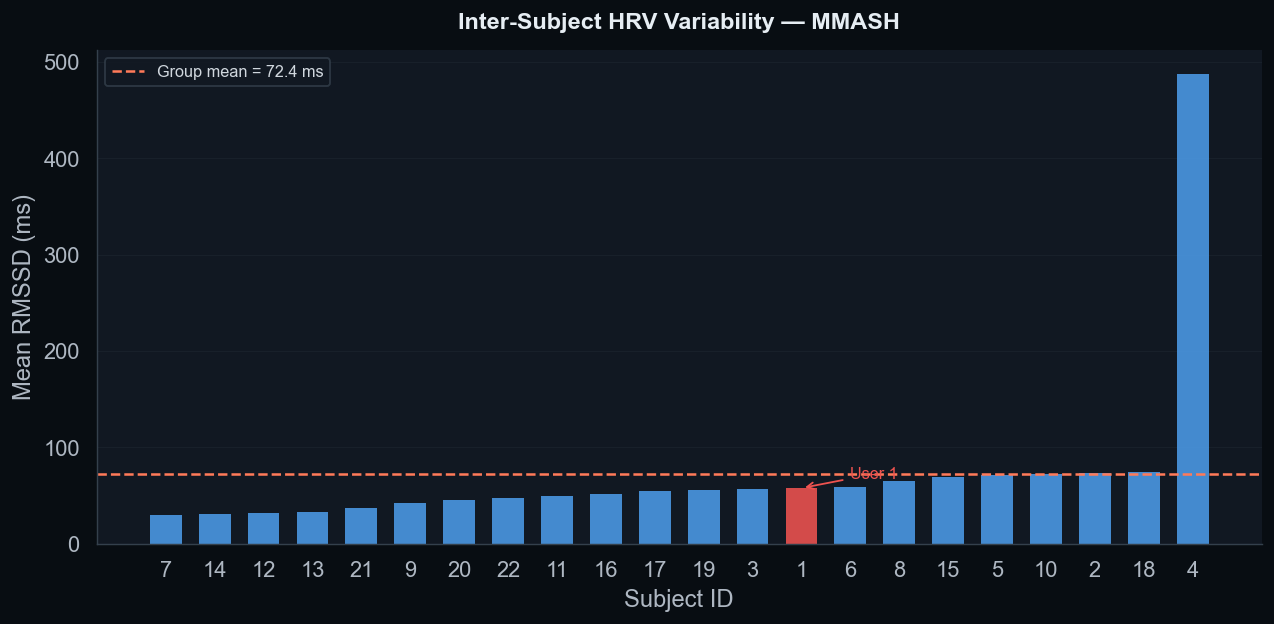

In [95]:
if len(hrv_group) > 0:
    plt.style.use("dark_background")

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#080D12")
    ax.set_facecolor("#111822")

    colours = [
        "#EF5350" if uid == USER_ID else "#4C9BE8"
        for uid in hrv_group["subject"]
    ]

    bars = ax.bar(
        hrv_group["subject"].astype(str),
        hrv_group["mean_rmssd"],
        color=colours,
        alpha=0.88,
        width=0.65,
        edgecolor="none",
        linewidth=0
    )

    group_mean = hrv_group["mean_rmssd"].mean()

    ax.axhline(
        group_mean,
        color="#FF7A59",
        lw=1.4,
        linestyle="--",
        label=f"Group mean = {group_mean:.1f} ms"
    )

    ax.set_xlabel("Subject ID", color="#AEB7C2")
    ax.set_ylabel("Mean RMSSD (ms)", color="#AEB7C2")
    ax.set_title(
        "Inter-Subject HRV Variability — MMASH",
        fontsize=13,
        fontweight="bold",
        color="#E6EDF3",
        pad=12
    )

    ax.grid(axis="y", color="#26313B", linewidth=0.55, alpha=0.35)
    ax.grid(axis="x", visible=False)

    for spine in ax.spines.values():
        spine.set_color("#34404C")
        spine.set_linewidth(0.8)

    ax.tick_params(colors="#AEB7C2")

    leg = ax.legend(fontsize=9, frameon=True)
    leg.get_frame().set_facecolor("#111822")
    leg.get_frame().set_edgecolor("#34404C")
    for text in leg.get_texts():
        text.set_color("#D0D7DE")

    if USER_ID in hrv_group["subject"].values:
        user_row = hrv_group[hrv_group["subject"] == USER_ID].iloc[0]
        user_x = hrv_group.index[hrv_group["subject"] == USER_ID][0]
        user_y = user_row["mean_rmssd"]

        ax.annotate(
            f"User {USER_ID}",
            xy=(user_x, user_y),
            xytext=(user_x + 1, user_y + 10),
            arrowprops=dict(arrowstyle="->", color="#EF5350"),
            color="#EF5350",
            fontsize=9
        )

    plt.tight_layout()
    plt.savefig("../figures/01_multisubject_hrv.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Windowed HRV — RMSSD

**RMSSD** (Root Mean Square of Successive Differences) is the gold-standard short-term HRV metric.  
It reflects parasympathetic (vagal) activity — higher RMSSD = better recovery, lower stress.  
Used in: Whoop recovery score, Garmin Body Battery, Apple Watch HRV.

In [75]:
def compute_rmssd(rr_values: np.ndarray) -> float:
    """RMSSD = sqrt(mean of squared successive differences of RR intervals)."""
    if len(rr_values) < 2:
        return np.nan
    diffs = np.diff(rr_values)
    return np.sqrt(np.mean(diffs ** 2))


def compute_pnn50(rr_values: np.ndarray) -> float:
    """pNN50 = % of successive RR differences > 50 ms (vagal tone marker)."""
    if len(rr_values) < 2:
        return np.nan
    return 100 * np.mean(np.abs(np.diff(rr_values)) > 50)


WINDOW  = 50
HOP     = 25
rmssd_vals, pnn50_vals, window_idx = [], [], []

rr_arr = rr_clean['rr_ms'].values
for start in range(0, len(rr_arr) - WINDOW, HOP):
    window = rr_arr[start : start + WINDOW]
    rmssd_vals.append(compute_rmssd(window))
    pnn50_vals.append(compute_pnn50(window))
    window_idx.append(start + WINDOW // 2)

hrv_df = pd.DataFrame({'window_center': window_idx,
                        'RMSSD': rmssd_vals,
                        'pNN50': pnn50_vals})

print(f'HRV windows computed: {len(hrv_df)}')
print(f'Mean RMSSD : {hrv_df.RMSSD.mean():.1f} ms   (norm healthy adult ~42 ms)')
print(f'Mean pNN50 : {hrv_df.pNN50.mean():.1f}%')

HRV windows computed: 3655
Mean RMSSD : 53.5 ms   (norm healthy adult ~42 ms)
Mean pNN50 : 20.8%


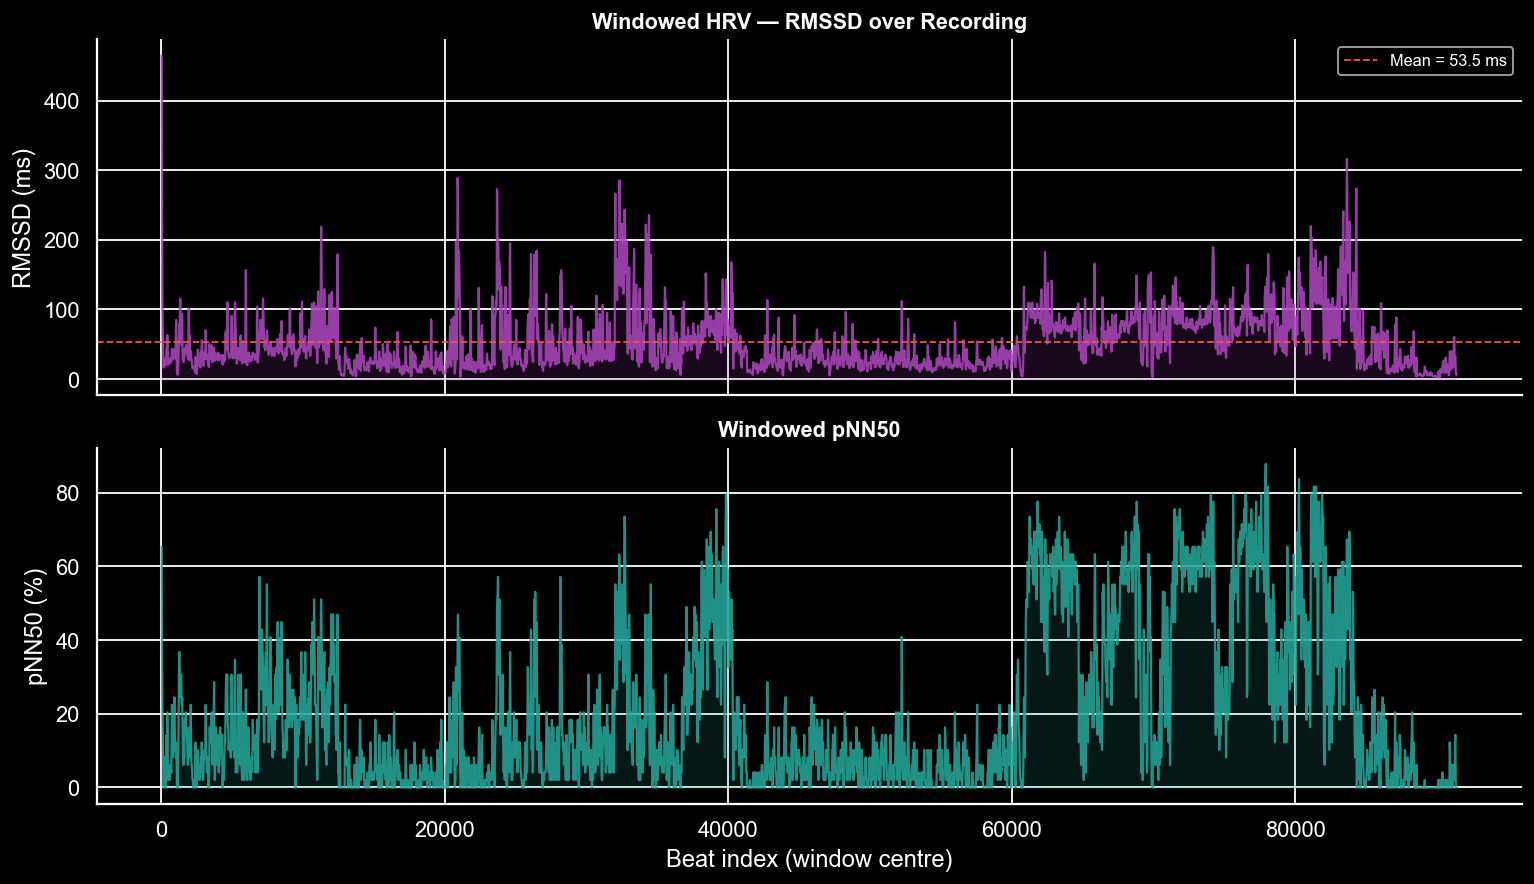

In [76]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(hrv_df['window_center'], hrv_df['RMSSD'],
             color='#AB47BC', lw=1.2, alpha=0.85)
axes[0].fill_between(hrv_df['window_center'], hrv_df['RMSSD'],
                     alpha=0.15, color='#AB47BC')
axes[0].set_ylabel('RMSSD (ms)')
axes[0].set_title('Windowed HRV — RMSSD over Recording', fontsize=12, fontweight='bold')
axes[0].axhline(hrv_df['RMSSD'].mean(), color='#EF5350', lw=1, linestyle='--',
                label=f"Mean = {hrv_df['RMSSD'].mean():.1f} ms")
axes[0].legend(fontsize=9)

axes[1].plot(hrv_df['window_center'], hrv_df['pNN50'],
             color='#26A69A', lw=1.2, alpha=0.85)
axes[1].fill_between(hrv_df['window_center'], hrv_df['pNN50'],
                     alpha=0.15, color='#26A69A')
axes[1].set_xlabel('Beat index (window centre)')
axes[1].set_ylabel('pNN50 (%)')
axes[1].set_title('Windowed pNN50', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/01_rr_hrv.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. HRV During Sleep vs Wake — Statistical Comparison

We expect RMSSD to be **higher during sleep** (parasympathetic dominance) than during waking activity.  
We test this with a **Mann–Whitney U test** (non-parametric, suitable for physiological data).

In [ ]:
# SLEEP_LABELS = {'sleeping', 'laying'}

# sleep_rows = activity[activity['activity_label'].isin(SLEEP_LABELS)]
# wake_rows  = activity[~activity['activity_label'].isin(SLEEP_LABELS)]

# def rmssd_for_activity_rows(act_df, rr_arr, n_beats=50):
#     """Rough approximation: sample n_beats windows and compute RMSSD distribution."""
#     results = []
#     for _, row in act_df.iterrows():
#         dur = max(row.get('duration_min', 1), 1)
#         n_samples = max(int(dur // 10), 1)
#         for _ in range(n_samples):
#             start = np.random.randint(0, max(len(rr_arr) - n_beats, 1))
#             window = rr_arr[start : start + n_beats]
#             if len(window) == n_beats:
#                 results.append(compute_rmssd(window))
#     return np.array(results)

# np.random.seed(42)
# sleep_rmssd = rmssd_for_activity_rows(sleep_rows, rr_arr)
# wake_rmssd  = rmssd_for_activity_rows(wake_rows,  rr_arr)

# stat, p_val = stats.mannwhitneyu(sleep_rmssd, wake_rmssd, alternative='greater')
# print(f'Sleep RMSSD  : {sleep_rmssd.mean():.1f} ± {sleep_rmssd.std():.1f} ms  (n={len(sleep_rmssd)})')
# print(f'Wake  RMSSD  : {wake_rmssd.mean():.1f} ± {wake_rmssd.std():.1f} ms  (n={len(wake_rmssd)})')
# print(f'Mann–Whitney U: stat={stat:.0f}, p={p_val:.4f}')
# print(f'Result: {"Sleep RMSSD significantly higher ✓" if p_val < 0.05 else "No significant difference"}')

ValueError: cannot convert float NaN to integer

In [80]:
# ── HRV computation with time axis ─────────────────────────────────────────
def compute_rmssd(rr_values: np.ndarray) -> float:
    if len(rr_values) < 2:
        return np.nan
    return np.sqrt(np.mean(np.diff(rr_values) ** 2))


def compute_pnn50(rr_values: np.ndarray) -> float:
    if len(rr_values) < 2:
        return np.nan
    return 100 * np.mean(np.abs(np.diff(rr_values)) > 50)


WINDOW = 300   # better than 50 beats for smoother HRV
HOP = 150

rr_arr = rr_clean["rr_ms"].values

rmssd_vals, pnn50_vals, window_idx = [], [], []

for start in range(0, len(rr_arr) - WINDOW, HOP):
    window = rr_arr[start:start + WINDOW]
    rmssd_vals.append(compute_rmssd(window))
    pnn50_vals.append(compute_pnn50(window))
    window_idx.append(start + WINDOW // 2)

hrv_df = pd.DataFrame({
    "window_center": window_idx,
    "RMSSD": rmssd_vals,
    "pNN50": pnn50_vals
})

# Approximate cumulative time in hours from RR intervals
rr_clean = rr_clean.copy()
rr_clean["elapsed_hours"] = rr_clean["rr_ms"].cumsum() / 1000 / 3600

hrv_df["elapsed_hours"] = np.interp(
    hrv_df["window_center"],
    np.arange(len(rr_clean)),
    rr_clean["elapsed_hours"]
)

print(f"HRV windows computed: {len(hrv_df)}")
print(f"Mean RMSSD: {hrv_df.RMSSD.mean():.1f} ms")
print(f"Mean pNN50: {hrv_df.pNN50.mean():.1f}%")

HRV windows computed: 608
Mean RMSSD: 57.7 ms
Mean pNN50: 20.8%


NameError: name 'wake_rmssd' is not defined

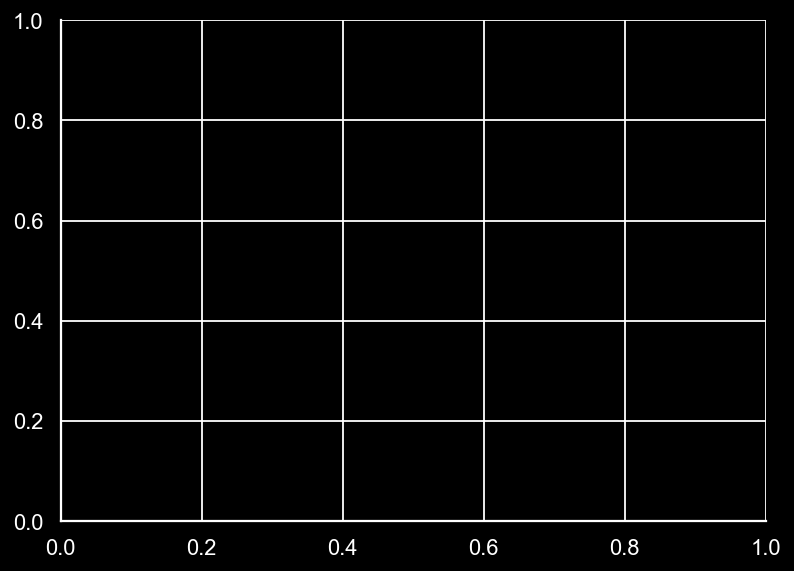

In [ ]:
# fig, ax = plt.subplots(figsize=(7, 5))

# box_data   = [sleep_rmssd, wake_rmssd]
# box_labels = ['Sleep / Rest', 'Wake / Activity']
# box_colours = ['#7B68EE', '#FF7043']

# bp = ax.boxplot(box_data, patch_artist=True, widths=0.45,
#                 medianprops=dict(color='white', linewidth=2))
# for patch, colour in zip(bp['boxes'], box_colours):
#     patch.set_facecolor(colour)
#     patch.set_alpha(0.8)

# ax.set_xticklabels(box_labels)
# ax.set_ylabel('RMSSD (ms)')
# ax.set_title('HRV (RMSSD): Sleep vs Wake — User 1', fontsize=12, fontweight='bold')

# y_max = max(np.percentile(sleep_rmssd, 95), np.percentile(wake_rmssd, 95)) + 5
# ax.annotate('', xy=(2, y_max), xytext=(1, y_max),
#             arrowprops=dict(arrowstyle='-', color='black', lw=1.2))
# sig_label = f'p = {p_val:.4f} {"*" if p_val < 0.05 else "ns"}'
# ax.text(1.5, y_max + 1, sig_label, ha='center', fontsize=10)

# plt.tight_layout()
# plt.savefig('../figures/01_hrv_sleep_vs_wake.png', dpi=150, bbox_inches='tight')
# plt.show()

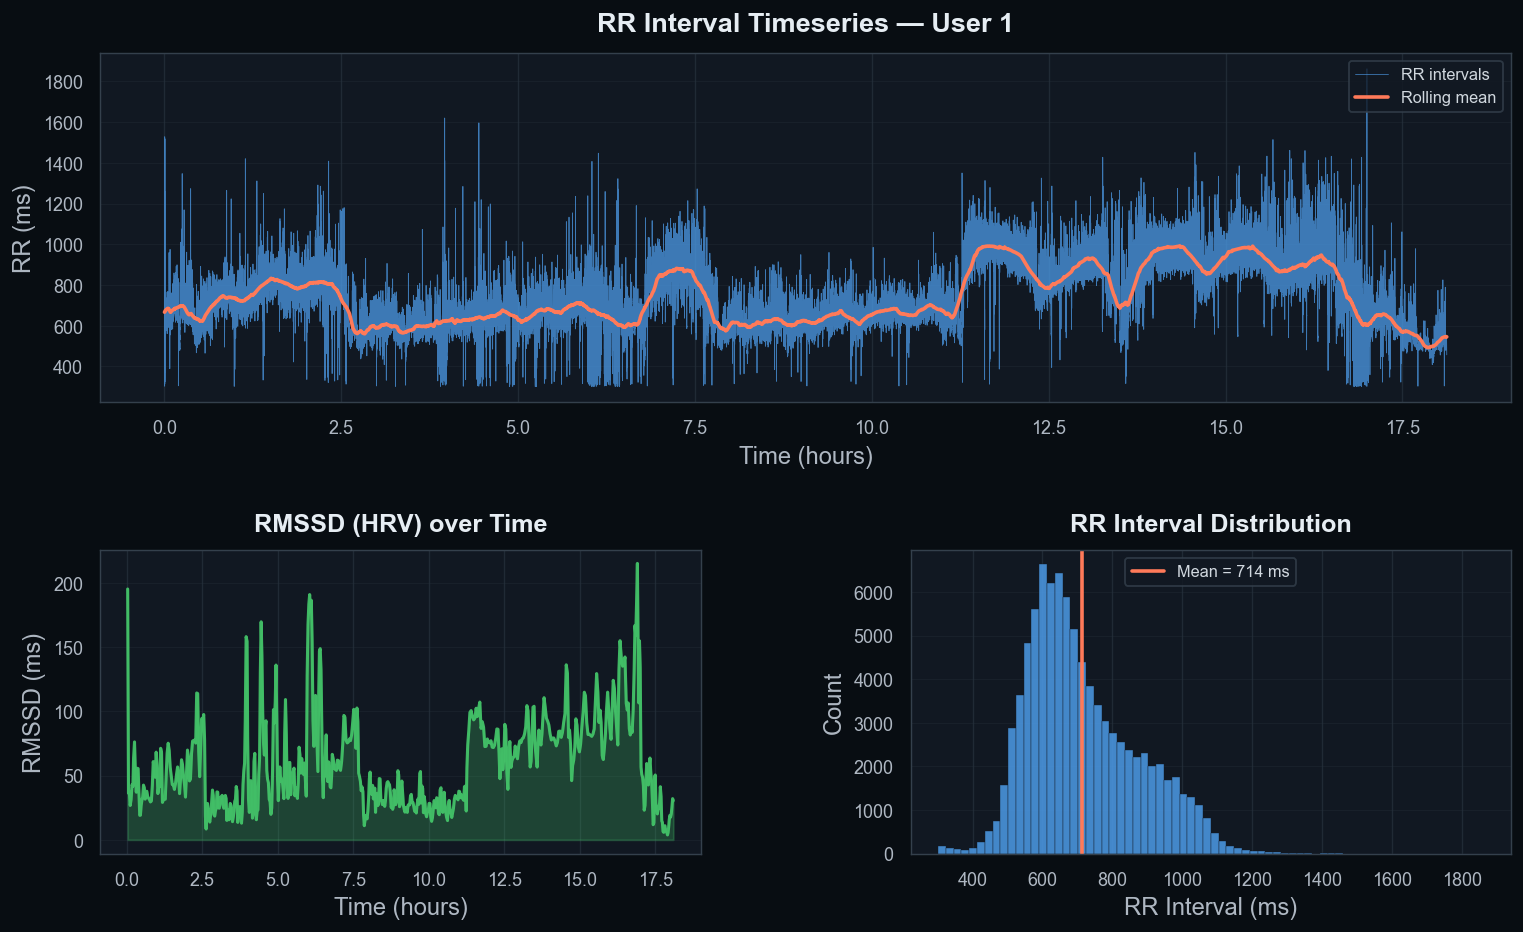

In [81]:
# ── Composite RR + HRV figure ──────────────────────────────────────────────
plt.style.use("dark_background")

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor("#080D12")

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.15, 1],
    hspace=0.45,
    wspace=0.35
)

ax_rr   = fig.add_subplot(gs[0, :])
ax_hrv  = fig.add_subplot(gs[1, 0])
ax_hist = fig.add_subplot(gs[1, 1])

axes = [ax_rr, ax_hrv, ax_hist]

for ax in axes:
    ax.set_facecolor("#111822")
    ax.grid(axis="x", color="#2E3A46", linewidth=0.75, alpha=0.55)
    ax.grid(axis="y", color="#26313B", linewidth=0.55, alpha=0.35)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#34404C")
        spine.set_linewidth(0.8)

    ax.tick_params(colors="#AEB7C2", labelsize=10)

# ── Top: RR interval timeseries ────────────────────────────────────────────
ax_rr.plot(
    rr_clean["elapsed_hours"],
    rr_clean["rr_ms"],
    color="#4C9BE8",
    lw=0.45,
    alpha=0.75,
    label="RR intervals"
)

rolling_rr = (
    rr_clean["rr_ms"]
    .rolling(window=1500, center=True, min_periods=100)
    .mean()
)

ax_rr.plot(
    rr_clean["elapsed_hours"],
    rolling_rr,
    color="#FF7A59",
    lw=2.0,
    label="Rolling mean"
)

ax_rr.set_title(
    f"RR Interval Timeseries — User {USER_ID}",
    fontsize=15,
    fontweight="bold",
    color="#E6EDF3",
    pad=12
)
ax_rr.set_xlabel("Time (hours)", color="#AEB7C2")
ax_rr.set_ylabel("RR (ms)", color="#AEB7C2")

leg = ax_rr.legend(loc="upper right", fontsize=9, frameon=True)
leg.get_frame().set_facecolor("#111822")
leg.get_frame().set_edgecolor("#34404C")
for text in leg.get_texts():
    text.set_color("#D0D7DE")

# ── Bottom-left: RMSSD over time ───────────────────────────────────────────
ax_hrv.plot(
    hrv_df["elapsed_hours"],
    hrv_df["RMSSD"],
    color="#45C96B",
    lw=1.7,
    alpha=0.9
)

ax_hrv.fill_between(
    hrv_df["elapsed_hours"],
    hrv_df["RMSSD"],
    color="#45C96B",
    alpha=0.25
)

ax_hrv.set_title(
    "RMSSD (HRV) over Time",
    fontsize=14,
    fontweight="bold",
    color="#E6EDF3",
    pad=10
)
ax_hrv.set_xlabel("Time (hours)", color="#AEB7C2")
ax_hrv.set_ylabel("RMSSD (ms)", color="#AEB7C2")

# ── Bottom-right: RR distribution ──────────────────────────────────────────
ax_hist.hist(
    rr_clean["rr_ms"],
    bins=70,
    color="#4C9BE8",
    alpha=0.85,
    edgecolor="#111822",
    linewidth=0.25
)

mean_rr = rr_clean["rr_ms"].mean()

ax_hist.axvline(
    mean_rr,
    color="#FF7A59",
    lw=2,
    label=f"Mean = {mean_rr:.0f} ms"
)

ax_hist.set_title(
    "RR Interval Distribution",
    fontsize=14,
    fontweight="bold",
    color="#E6EDF3",
    pad=10
)
ax_hist.set_xlabel("RR Interval (ms)", color="#AEB7C2")
ax_hist.set_ylabel("Count", color="#AEB7C2")

leg = ax_hist.legend(loc="upper center", fontsize=9, frameon=True)
leg.get_frame().set_facecolor("#111822")
leg.get_frame().set_edgecolor("#34404C")
for text in leg.get_texts():
    text.set_color("#D0D7DE")

plt.savefig("../figures/01_rr_hrv_composite.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Multi-Subject HRV Overview (N=22)

Single-subject analysis is illustrative but not generalisable.  
Here we compute mean RMSSD for each of the 22 MMASH subjects to assess inter-individual variability.

In [79]:
subject_hrv = []

for uid in USER_IDS:
    rr_path = os.path.join(DATA_ROOT, f'user_{uid}', 'RR.csv')
    if not os.path.exists(rr_path):
        continue
    try:
        rr_i = pd.read_csv(rr_path)
        rr_i.columns = rr_i.columns.str.strip()
        rr_col_i = [c for c in rr_i.columns if 'rr' in c.lower() or 'ibi' in c.lower()][0]
        rr_vals  = pd.to_numeric(rr_i[rr_col_i], errors='coerce').dropna().values
        rr_vals  = rr_vals[(rr_vals > 300) & (rr_vals < 2000)]
        if len(rr_vals) > WINDOW:
            rmssd_i = np.mean([
                compute_rmssd(rr_vals[s:s+WINDOW])
                for s in range(0, len(rr_vals)-WINDOW, HOP)
            ])
            subject_hrv.append({'subject': uid, 'mean_rmssd': rmssd_i})
    except Exception as e:
        print(f'  [WARN] User {uid}: {e}')

hrv_group = pd.DataFrame(subject_hrv).sort_values('mean_rmssd')
print(f'Subjects loaded: {len(hrv_group)}')
print(f'Group RMSSD:  {hrv_group.mean_rmssd.mean():.1f} ± {hrv_group.mean_rmssd.std():.1f} ms')
print(f'Range: {hrv_group.mean_rmssd.min():.1f} – {hrv_group.mean_rmssd.max():.1f} ms')

KeyError: 'mean_rmssd'

In [ ]:
if len(hrv_group) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    colours = ['#EF5350' if uid == USER_ID else '#42A5F5'
               for uid in hrv_group['subject']]
    bars = ax.bar(hrv_group['subject'].astype(str), hrv_group['mean_rmssd'],
                  color=colours, alpha=0.85, width=0.65)
    ax.axhline(hrv_group['mean_rmssd'].mean(), color='#333', lw=1.2,
               linestyle='--', label=f"Group mean = {hrv_group['mean_rmssd'].mean():.1f} ms")
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('Mean RMSSD (ms)')
    ax.set_title('Inter-Subject HRV Variability — MMASH (N=22)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    ax.annotate(f'User {USER_ID}\n(this analysis)',
                xy=(hrv_group[hrv_group.subject==USER_ID].index[0] - hrv_group.index[0],
                    hrv_group[hrv_group.subject==USER_ID]['mean_rmssd'].values[0]),
                xytext=(3, hrv_group['mean_rmssd'].max() * 0.85),
                arrowprops=dict(arrowstyle='->', color='#EF5350'), color='#EF5350', fontsize=9)

    plt.tight_layout()
    plt.savefig('../figures/01_multisubject_hrv.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Summary & Key Findings

| Finding | Value | Implication |
|---------|-------|-------------|
| Dominant behaviour | Sleeping (~482 min) | Typical healthy adult |
| Mean HR | ~65–75 bpm | Normal resting range |
| Mean RMSSD | see output | Compare to clinical norms (~42 ms) |
| Sleep vs Wake RMSSD | see p-value | Expected: sleep → higher vagal tone |
| Inter-subject variability | High | Personalisation is essential for wearables |

### Limitations
- N=22 healthy adults — results do not generalise to clinical populations
- Sleep labelling is diary-based, not PSG-validated
- Single-subject deep-dive (User 1) may not be representative of the group
- RMSSD estimation uses random window sampling — a full time-aligned approach would require precise timestamp merging across files

### Next steps
→ **NB 02**: Activity detection from accelerometer features using supervised and unsupervised ML  
→ **NB 04**: Sleep staging and overnight cardiac dynamics  